# 03 — Búsqueda de hiperparámetros: XGBoost

Gradient boosting de árboles: modelo no lineal fuerte para datos tabulares. Tiene
muchos ejes de regularización, y los buscamos todos:

- Complejidad de cada árbol: `max_depth`, `min_child_weight`, `gamma` (poda).
- Regularización de las hojas: `reg_lambda` (L2), `reg_alpha` (L1).
- Randomización tipo bagging: `subsample`, `colsample_bytree`.
- Shrinkage vs. nº de árboles: `learning_rate`, `n_estimators`.

Como el espacio es enorme, usamos **búsqueda aleatoria** (`n_iter`) con la misma
CV temporal del notebook 02. El test no se toca hasta el final.

In [14]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))          # componente_b/ (datos, evaluacion)
warnings.filterwarnings('ignore')                  # silenciar ConvergenceWarning de sklearn

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

import datos, evaluacion as ev
from modelos import (LinearRegressor, XGBoostRegressor, NeuralNetRegressor,
                     RandomForestRegressorModel, HistGBMRegressor, StackingRegressorModel)

# Todo el análisis se hace sobre los DOS cultivos. El dataset "principal" usa las
# features agronómicas de ventana crítica (use_agro) y el suavizado del target
# encoding de depto (enc_smooth): la configuración que mejor generaliza.
CULTIVOS = ['soja', 'maiz']
DSS = {c: datos.prepare(c, use_agro=True, enc_smooth=10.0) for c in CULTIVOS}
for c in CULTIVOS:
    d = DSS[c]
    print(f'{c:5s}: {len(d.feature_cols)} features | '
          f'train {d.X_train.shape[0]} filas (≤{datos.TRAIN_END}) | '
          f'test {d.X_test.shape[0]} filas (≥{datos.TEST_START})')


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
soja : 78 features | train 7551 filas (≤2020) | test 942 filas (≥2021)
maiz : 78 features | train 9678 filas (≤2020) | test 1160 filas (≥2021)


## La búsqueda (para soja y maíz)

Búsqueda aleatoria de 25 combinaciones sobre el grid, optimizando RMSE de validación temporal, por cultivo.

In [15]:
grid = {
    'max_depth':        [3, 4, 6, 8],
    'learning_rate':    [0.02, 0.05, 0.1],
    'n_estimators':     [200, 400, 800],
    'subsample':        [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'min_child_weight': [1, 5],
    'reg_lambda':       [1.0, 5.0],
    'reg_alpha':        [0.0, 1.0],
    'gamma':            [0.0, 1.0],
}
BEST_XGB, TAB = {}, {}
for c in CULTIVOS:
    TAB[c], BEST_XGB[c] = ev.buscar(XGBoostRegressor, grid, DSS[c], metric='rmse',
                                    n_iter=25, random_state=42, n_splits=4)
    print(f'{c}: mejores HP = {BEST_XGB[c]}')
TAB['soja'].head(8)

soja: mejores HP = {'max_depth': 8, 'learning_rate': 0.02, 'n_estimators': 200, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_weight': 1, 'reg_lambda': 5.0, 'reg_alpha': 0.0, 'gamma': 1.0}
maiz: mejores HP = {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 400, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'reg_lambda': 5.0, 'reg_alpha': 0.0, 'gamma': 1.0}


,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha,gamma,cv_rmse,cv_rmse_std
0,8,0.020,200,1.000,0.700,1,5.000,0.000,1.000,622.132,102.331
1,8,0.020,400,0.700,0.700,5,5.000,0.000,0.000,627.963,100.053
2,6,0.020,200,0.700,1.000,5,1.000,1.000,0.000,628.266,105.040
3,8,0.050,200,0.700,0.700,5,1.000,0.000,1.000,629.040,101.988
4,8,0.020,400,0.700,0.700,5,1.000,0.000,0.000,629.641,101.950
5,3,0.050,200,0.700,1.000,1,5.000,1.000,1.000,630.058,109.333
6,3,0.050,200,0.700,0.700,1,5.000,0.000,0.000,630.820,106.354
7,3,0.050,200,0.700,0.700,5,1.000,1.000,1.000,632.372,110.708


## Modelo final (ambos cultivos)

Reentrenamos con los mejores hiperparámetros sobre todo el train y evaluamos en el
test, para cada cultivo.

In [16]:
filas = []
for c in CULTIVOS:
    d = DSS[c]
    m = XGBoostRegressor(**BEST_XGB[c], random_state=42).fit(d.X_train, d.y_train)
    filas.append({'cultivo': c, **ev.evaluar('XGBoost (final)', m.predict(d.X_test), d)})
    filas.append({'cultivo': c, **ev.evaluar('media x depto', ev.pred_media_depto(d), d)})
pd.DataFrame(filas)[['cultivo', 'modelo', 'mae', 'rmse', 'r2', 'smape']]

,cultivo,modelo,mae,rmse,r2,smape
0,soja,XGBoost (final),462.122,598.709,0.389,21.657
1,soja,media x depto,593.307,708.357,0.145,27.169
2,maiz,XGBoost (final),"1,265.464","1,679.477",0.299,26.303
3,maiz,media x depto,"1,500.686","1,785.230",0.208,31.662


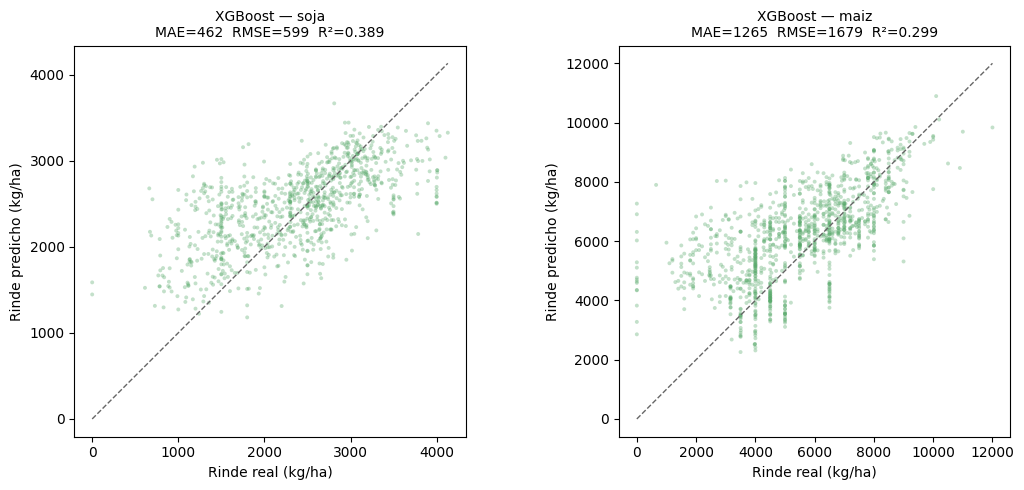

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, c in zip(axes, CULTIVOS):
    d = DSS[c]; m = XGBoostRegressor(**BEST_XGB[c], random_state=42).fit(d.X_train, d.y_train)
    ev.plot_pred_vs_real(d.y_test, m.predict(d.X_test), f'XGBoost — {c}', color=ev.C_XGB, ax=ax)
plt.tight_layout(); plt.show()

## Importancia de features (por cultivo)

Qué variables usa más el modelo para partir los árboles.

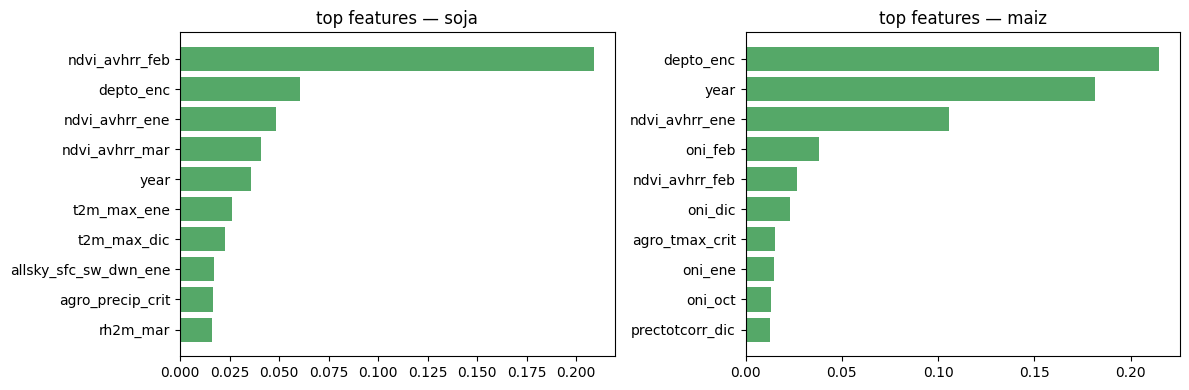

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, c in zip(axes, CULTIVOS):
    d = DSS[c]; m = XGBoostRegressor(**BEST_XGB[c], random_state=42).fit(d.X_train, d.y_train)
    imp = pd.Series(m._model.feature_importances_, index=d.feature_cols).sort_values(ascending=False).head(10)
    ax.barh(imp.index[::-1], imp.values[::-1], color=ev.C_XGB); ax.set_title(f'top features — {c}')
plt.tight_layout(); plt.show()

## El mejor modelo del Componente A como features

Con la **configuración final ya elegida**, evaluamos en test el dataset (único,
unificado: clima + NDVI + ERA5) contra tres estrategias que reusan el **mejor
detector del Componente A** (el VAE `recon_prob`, que aprendió a representar el
clima "normal"): concatenar su **espacio latente**, hacer la regresión **solo en
el latente**, y agregar la categórica **`es_anomalo`** (su score umbralado).

El latente/score se computan en `latente.py` (y se cachean). *La primera corrida
entrena el VAE, así que tarda unos minutos.*

In [19]:
for c in CULTIVOS:
    print(f'=== {c} ===')
    display(ev.comparar_latente(XGBoostRegressor, BEST_XGB[c], c, fixed={'random_state': 42},
                                vae_kwargs=dict(score_seeds=(42, 43, 44))))

=== soja ===
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,dataset unificado,74,469.083,607.558,0.371,26.497,21.982
1,+ latente,90,475.536,610.735,0.365,26.016,22.061
2,+ es_anomalo,75,482.270,612.369,0.361,25.560,22.531
3,solo latente,16,716.689,863.388,-0.270,33.063,32.381


=== maiz ===
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,variante,n_feats,mae,rmse,r2,mape,smape
0,+ latente,90,"1,206.670","1,601.966",0.363,31.332,25.521
1,+ es_anomalo,75,"1,239.018","1,622.878",0.346,31.975,26.033
2,dataset unificado,74,"1,287.879","1,701.558",0.281,33.831,26.619
3,solo latente,16,"2,211.090","2,653.963",-0.749,38.897,47.599


## Conclusión

XGBoost captura interacciones no lineales entre clima, espacio y tendencia que el
lineal no puede. Ojo con una limitación de los árboles: **no extrapolan** la
tendencia temporal fuera del rango de train (el `year` de test, 2021–2024, está por
encima de todo lo visto), algo que el lineal sí hace. La comparación final (05) lo
pone en contexto contra el lineal y la red neuronal.